<a href="https://colab.research.google.com/github/Hajer5503/AgriSmart/blob/feature%2Fcrop-disease-detection/modules/crop_disease_detection/notebooks/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AgriSmart – Crop Disease Detection  
## 01. Data Exploration

### Context
This notebook explores the image dataset used for crop disease detection in the AgriSmart project.  
The dataset consists of labeled images organized by crop and disease type, including healthy samples.

### Objectives
- Inspect dataset structure
- Analyze class distribution
- Visualize sample images
- Identify potential data imbalance issues


In [1]:
import os
import random
from collections import Counter
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import drive
drive.mount('/content/drive')


MessageError: Error: credential propagation was unsuccessful

In [2]:
DATASET_PATH = "C:\Users\hajer\OneDrive\Documents\GitHub\Crop disease"

print("Classes found:")
for cls in os.listdir(DATASET_PATH):
    print("-", cls)


SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (ipython-input-2957006951.py, line 1)

In [3]:
class_counts = {}

for cls in os.listdir(DATASET_PATH):
    cls_path = os.path.join(DATASET_PATH, cls)
    if os.path.isdir(cls_path):
        class_counts[cls] = len(os.listdir(cls_path))

class_counts


NameError: name 'DATASET_PATH' is not defined

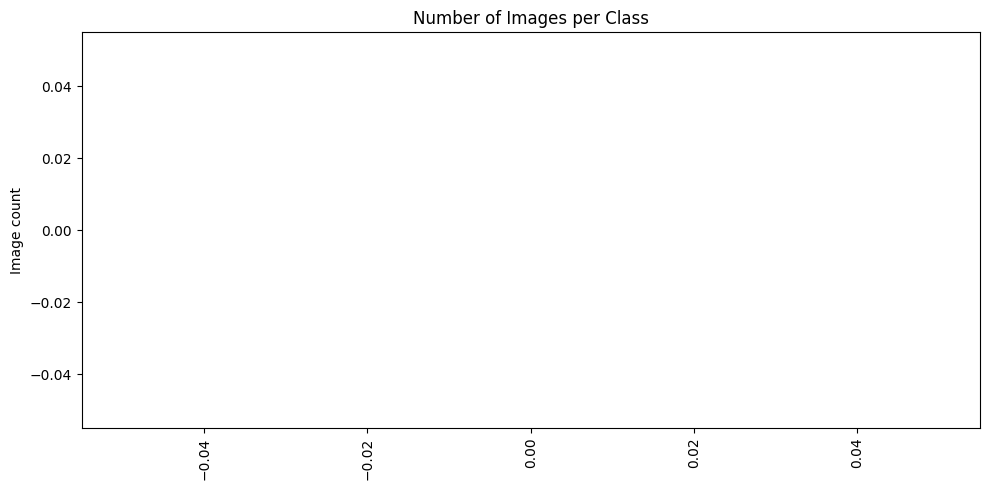

In [4]:
plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90)
plt.title("Number of Images per Class")
plt.ylabel("Image count")
plt.tight_layout()
plt.show()


### Class Distribution Analysis

The dataset shows varying numbers of images across different disease classes and healthy samples.
This imbalance may affect model training and will be addressed later using data augmentation
and appropriate evaluation metrics.


In [5]:
def show_random_images(dataset_path, n=5):
    classes = os.listdir(dataset_path)
    plt.figure(figsize=(15, 3))

    for i in range(n):
        cls = random.choice(classes)
        img_name = random.choice(os.listdir(os.path.join(dataset_path, cls)))
        img_path = os.path.join(dataset_path, cls, img_name)

        img = Image.open(img_path)
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")

    plt.show()

show_random_images(DATASET_PATH, n=5)


NameError: name 'DATASET_PATH' is not defined

### Initial Observations

- Images are well-labeled and organized by class.
- Visual inspection confirms clear differences between healthy and diseased crops.
- Image sizes and lighting conditions vary, suggesting the need for resizing and normalization.
- Data augmentation may be beneficial for underrepresented classes.
